In [1]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

In [2]:
X, y = fetch_openml('mnist_784', version=1, return_X_y=True)
X = X.astype(np.float32) / 255.0
y = y.astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=10000)

In [3]:
def one_hot(y, num_classes=10):
    oh = np.zeros((y.size, num_classes))
    oh[np.arange(y.size), y] = 1
    return oh

y_train_oh = one_hot(y_train)

In [5]:
class DeepMLP:
    def __init__(self, lr=0.01):
        self.lr = lr


        self.W1 = np.random.randn(784, 256) * np.sqrt(2/784)
        self.b1 = np.zeros((1, 256))

        self.W2 = np.random.randn(256, 128) * np.sqrt(2/256)
        self.b2 = np.zeros((1, 128))

        self.W3 = np.random.randn(128, 64) * np.sqrt(2/128)
        self.b3 = np.zeros((1, 64))

        self.W4 = np.random.randn(64, 10) * np.sqrt(2/64)
        self.b4 = np.zeros((1, 10))


    def relu(self, x):
        return np.maximum(0, x)

    def relu_deriv(self, x):
        return (x > 0).astype(float)

    def softmax(self, x):
        exp = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp / np.sum(exp, axis=1, keepdims=True)


    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.relu(self.z1)

        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.relu(self.z2)

        self.z3 = self.a2 @ self.W3 + self.b3
        self.a3 = self.relu(self.z3)

        self.z4 = self.a3 @ self.W4 + self.b4
        self.a4 = self.softmax(self.z4)

        return self.a4


    def loss(self, y, y_pred):
        return -np.mean(np.sum(y * np.log(y_pred + 1e-8), axis=1))


    def backward(self, X, y):
        m = X.shape[0]

        dz4 = self.a4 - y
        dW4 = (self.a3.T @ dz4) / m
        db4 = np.sum(dz4, axis=0, keepdims=True) / m

        dz3 = (dz4 @ self.W4.T) * self.relu_deriv(self.z3)
        dW3 = (self.a2.T @ dz3) / m
        db3 = np.sum(dz3, axis=0, keepdims=True) / m

        dz2 = (dz3 @ self.W3.T) * self.relu_deriv(self.z2)
        dW2 = (self.a1.T @ dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        dz1 = (dz2 @ self.W2.T) * self.relu_deriv(self.z1)
        dW1 = (X.T @ dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m


        self.W4 -= self.lr * dW4
        self.b4 -= self.lr * db4

        self.W3 -= self.lr * dW3
        self.b3 -= self.lr * db3

        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1


    def fit(self, X, y, epochs=10, batch_size=64):
        for epoch in range(epochs):
            idx = np.random.permutation(len(X))
            X, y = X[idx], y[idx]

            for i in range(0, len(X), batch_size):
                Xb = X[i:i+batch_size]
                yb = y[i:i+batch_size]

                self.forward(Xb)
                self.backward(Xb, yb)

            loss = self.loss(y, self.forward(X))
            print(f"Epoch {epoch+1}: Loss = {loss:.4f}")


    def predict(self, X):
        return np.argmax(self.forward(X), axis=1)



In [8]:
model = DeepMLP()
model.fit(X_train.to_numpy(), y_train_oh, epochs=20)

Epoch 1: Loss = 0.3507
Epoch 2: Loss = 0.2598
Epoch 3: Loss = 0.2197
Epoch 4: Loss = 0.1897
Epoch 5: Loss = 0.1680
Epoch 6: Loss = 0.1516
Epoch 7: Loss = 0.1355
Epoch 8: Loss = 0.1345
Epoch 9: Loss = 0.1153
Epoch 10: Loss = 0.1041
Epoch 11: Loss = 0.0982
Epoch 12: Loss = 0.0923
Epoch 13: Loss = 0.0854
Epoch 14: Loss = 0.0818
Epoch 15: Loss = 0.0769
Epoch 16: Loss = 0.0705
Epoch 17: Loss = 0.0668
Epoch 18: Loss = 0.0670
Epoch 19: Loss = 0.0637
Epoch 20: Loss = 0.0562


In [12]:

preds = model.predict(X_test.to_numpy())
acc = np.mean(preds == y_test.to_numpy())

print(f"Accuracy: {acc*100:.2f}%")

Accuracy: 97.36%


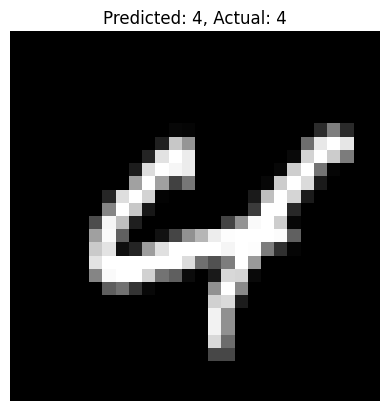

In [20]:
import matplotlib.pyplot as plt

# Pick random test image
idx = np.random.randint(9, X_test.shape[0])
image = X_test.to_numpy()[idx]
true_label = y_test.to_numpy()[idx]

# Predict
pred = model.predict(image.reshape(1, -1))[0]

# Show image
plt.imshow(image.reshape(28, 28), cmap='gray')
plt.title(f"Predicted: {pred}, Actual: {true_label}")
plt.axis('off')
plt.show()